In [2]:
import sys
sys.path.append('../src/pinn')
sys.path.append('../src/data_generation')

Making Movie...


  0%|          | 0/61 [00:00<?, ?it/s]

/gscratch/matsulab/envs/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


KeyboardInterrupt: 

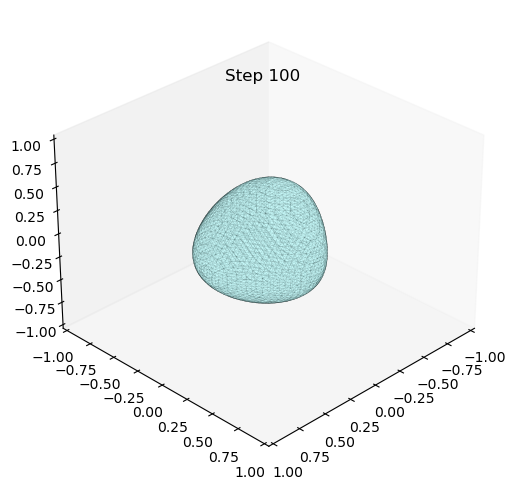

In [3]:
# Make a movie

import matplotlib.pyplot as plt
import os
from pinn.plot import plot_3d_isosurface
from flax.training import checkpoints
import imageio
import re
from tqdm.auto import tqdm 

shape = "bud_04"
lambda_1 = 1000000
lambda_2 = 50

steps_to_visualize = list(range(0, 6001, 100))
# log_dir = os.path.abspath(f"../outputs/logs/{shape}/flip/f02/lambda_{lambda_1}_{lambda_2}/")
log_dir = os.path.abspath(f"../outputs/logs/{shape}/trial_0919/flip_0175/lambda_{lambda_1}_{lambda_2}/")
frame_dir = os.path.join(log_dir, f"frames")

def save_isosurface_frame(step, checkpoint, save_dir="frames", grid_size=64):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint, grid_size)
    
    os.makedirs(save_dir, exist_ok=True)
    filename = os.path.join(save_dir, f"frame_{step:06d}.png")
    plt.savefig(filename, dpi=150)
    plt.close(fig)

def make_movie_from_frames(frame_dir="frames", output="movie.mp4", fps=12, start=0, end=30000):
    # Match files like frame_XXXX.png and extract the numeric part
    pattern = re.compile(r"frame_(\d+)\.png")

    frames = []
    for fname in os.listdir(frame_dir):
        match = pattern.match(fname)
        if match:
            index = int(match.group(1))
            if start <= index <= end:
                frames.append((index, os.path.join(frame_dir, fname)))

    frames.sort(key=lambda x: x[0])

    with imageio.get_writer(output, fps=fps) as writer:
        for _, frame_path in frames:
            image = imageio.imread(frame_path)
            writer.append_data(image)

print("Making Movie...")
for step in tqdm(steps_to_visualize, total=len(steps_to_visualize)):
    ckpt_path = os.path.join(log_dir, f"checkpoint_{step}")
    ckpt_data = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=None)
    # print(f"saving step {step}")
    save_isosurface_frame(step, ckpt_data, save_dir=frame_dir)

output=os.path.abspath(f"{frame_dir}/movie.mp4")
make_movie_from_frames(frame_dir=frame_dir, output=output)